# Installation

In [ ]:
pip install devito

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.9/132.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.0 MB/s eta 0:00:00
  Created wheel for cgen: filename=cgen-2025.1-py3-none-any.whl size=19883 sha256=7d2b102c1ef0b7ece7a87b14a9a7dd771731ce0432ae44284f76f722e027954e
  Stored in directory: /root/.cache/pip/wheels/50/1a/02/97f23c102994cf34e52e405bc2e2889aaf463fdcb37d23ca3a
  Created wheel for codepy: filename=codepy-2023.1-py3-none-any.whl size=24869 sha256=845a2dc6961555ed5f11d935e66bbe9371423f526d14cdc0e68c8c4d50a1c503
  Stored in directory:

In [ ]:
pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 8.5 MB/s eta 0:00:00


# Definições

In [ ]:
#------------------- Bibliotecas utilizadas --------------------------
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from scipy.sparse import diags
from IPython.display import display, Math, Latex

import scipy as sc
from scipy.sparse.linalg import cg
from scipy.sparse import csr_matrix
from scipy.linalg import toeplitz

import time
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from google.colab import files
from collections import Counter

%matplotlib inline

from devito import Grid, Function, TimeFunction, Operator, configuration, Eq, solve, Constant
from sympy import nsimplify, pprint
from devito.logger import warning
from examples.cfd import plot_field, init_hat

In [ ]:
def norma_gridfunctions(h, k, matriz_erro, q):

    sum_erro = sum(sum(matriz_erro**q));
    interno  = h*k*sum_erro;

    norma = (interno)**(1/q);

    return norma

def definida_positiva(A):
    Lambdas = la.eigvals(A);
    is_pos_eigvals = np.all(Lambdas > 0);
    if is_pos_eigvals == False:
        #return False;
        print('Os autovalores nao sao positivos, logo a matriz A nao e definida positiva');
    if is_pos_eigvals == True:
        #return True;
        print('Os autovalores sao positivos, logo a matriz A e definida positiva.');
    #print('Os autovalores sao: ' ,Lambdas);

def definida_negativa(A):
    Lambdas = la.eigvals(A);
    is_neg_eigvals = np.all(Lambdas < 0);
    if is_neg_eigvals == False:
        print('Os autovalores nao sao negativos, logo a matriz A nao e definida negativa');
    if is_neg_eigvals == True:
        print('Os autovalores sao negativos, logo a matriz A e definida negativa.');
    #print('Os autovalores sao: ' ,Lambdas);

def verific_simetrica(A):
    for i in range(len(A)):
        for j  in range(len(A[0])):
            if A[i][j] != A[j][i]:
                #return False
                print('A matriz nao e simetrica');
    #return True
    print('A matriz e simetrica');

def plot3D(X, Y, w_ex, f):
    fig = plt.figure(figsize=(7, 7), dpi=100)
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, f[:].T, rstride=1, cstride=1, cmap="viridis",
            linewidth=0, antialiased=False)
    ax.scatter3D(X, Y, w_ex, color = "red", label = 'Solução Numerica');              #Pontos da Solucao Analitica
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    plt.savefig('Figura Solucao 3d.png', transparent=True, dpi=300);
    files.download('Figura Solucao 3d.png') #fazendo download do arquivo gerado no google colab
    plt.show()

def plot_3d_comparison(x, y, numerical_solution, analytical_solution):
    """
    Plota comparação 3D entre solução numérica (superfície) e analítica (pontos)

    Parâmetros:
    x : array 1D - coordenadas x da malha
    y : array 1D - coordenadas y da malha
    numerical_solution : array 2D - solução numérica em toda a malha
    analytical_solution : array 2D - solução analítica em toda a malha
    """
    # Cria malha para plotagem 3D
    X, Y = np.meshgrid(x, y, indexing='ij')

    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plota superfície da solução numérica
    surf = ax.plot_surface(X, Y, analytical_solution.T,
                          cmap='viridis', alpha=0.7,
                          label='Solução Analítica')

    # Plota pontos da solução analítica (mostrando 1 a cada 2 pontos para melhor visualização)
    scatter = ax.scatter(X[::2,::2], Y[::2,::2], numerical_solution.T[::2,::2],
                        color='red', s=50, depthshade=True,
                        label='Solução Numérica')

    # Configurações do gráfico
    ax.set_xlabel(r'x', fontsize=12)
    ax.set_ylabel(r'y', fontsize=12)
    ax.set_zlabel(r'p(x,y)', fontsize=12)
    #ax.set_title('Solução Numérica vs Analítica', fontsize=14)

    # Criando legendas manualmente
    surf._edgecolors2d = surf._edgecolor3d
    surf._facecolors2d = surf._facecolor3d
    ax.legend()

    # Ajusta a visualização
    ax.view_init(elev=20, azim=60)
    plt.tight_layout()
    plt.show()

# Equação de Poisson

$$ \dfrac{\partial ^2 p}{\partial x^2} + \dfrac{\partial ^2 p}{\partial y^2}  =  (6x-4)(y^3-2y^2+y) + (6y-4)(x^3-2x^2+x) $$

c.c. Dirichlet; $[0,1]$x$[0,1]$

# Devito

In [ ]:
nx = 11
ny = nx
xmin, xmax = 0., 1.
ymin, ymax = 0., 1.

compx = xmax - xmin
compy = ymax - ymin

dx = (compx) / (nx -1)
dy = (compy) / (ny -1)

x_ = np.linspace(xmin, xmax, nx)
y_ = np.linspace(ymin, ymax, ny)

X, Y = np.meshgrid(x_,y_,indexing='ij')

sigma = 0.1
dt = (sigma * dx * dy)
tstop = 1
nt = round(tstop / dt)
print(x_, compx, dx)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ] 1.0 0.1


In [ ]:
# Silence the runtime performance logging
configuration['log-level'] = 'ERROR'


grid = Grid(shape=(nx, ny), extent=(compx, compy))
p = TimeFunction(name='p', grid=grid, space_order=2)
p.data[:] = 0.
x, y = grid.dimensions
t = grid.stepping_dim

f = Function(name='f', shape=(nx,ny), dimensions=(x,y), grid = grid)
f_data = (6*X-4)*(Y**3-2*Y**2+Y) + (6*Y-4)*(X**3-2*X**2+X)
f.data[:] = f_data.reshape((nx, ny))

print(grid)
print(p)

eq = Eq(p.laplace, f)
stencil = solve(eq, p)
eq_stencil = Eq(p.forward, stencil)

# Boundary condition expressions

bc = [Eq(p[t + 1, x, 0], 0.)]   # y
bc += [Eq(p[t + 1, x, ny-1], 0.)]

bc += [Eq(p[t + 1, 0, y], 0.)]    # x
bc += [Eq(p[t + 1, nx-1, y], 0.)]

#configuration['log-level'] = 'ERROR'
# Create and execute the operator for a number of timesteps
op = Operator([eq_stencil] + bc)
inicio = time.time()
%time op(time=nt)
fim = time.time()
print(fim-inicio)
#op(time=nt)

plot_field(p.data[0], xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax, view=(30,225))
#print(p.data[0, :, :, :])

Grid[extent=(np.float32(1.0), np.float32(1.0)), shape=(11, 11), dimensions=(x, y)]
p(t, x, y)
CPU times: user 85.1 ms, sys: 8.34 ms, total: 93.4 ms
Wall time: 864 ms
0.8655946254730225


In [ ]:
f_analytical = X*((X-1)**2)*Y*((Y-1)**2)
#relative_error = np.sqrt(np.sum((T_analytical[:,ny//2] - u.data[0,:,ny//2])**2 ))
#error = np.linalg.norm(f_analytical - p.data[0]) / np.linalg.norm(f_analytical)
error = np.sqrt(np.sum((f_analytical - p.data)**2 )) / np.sqrt(np.sum((f_analytical)**2 ))
print(error)

5.817001775959357e-07


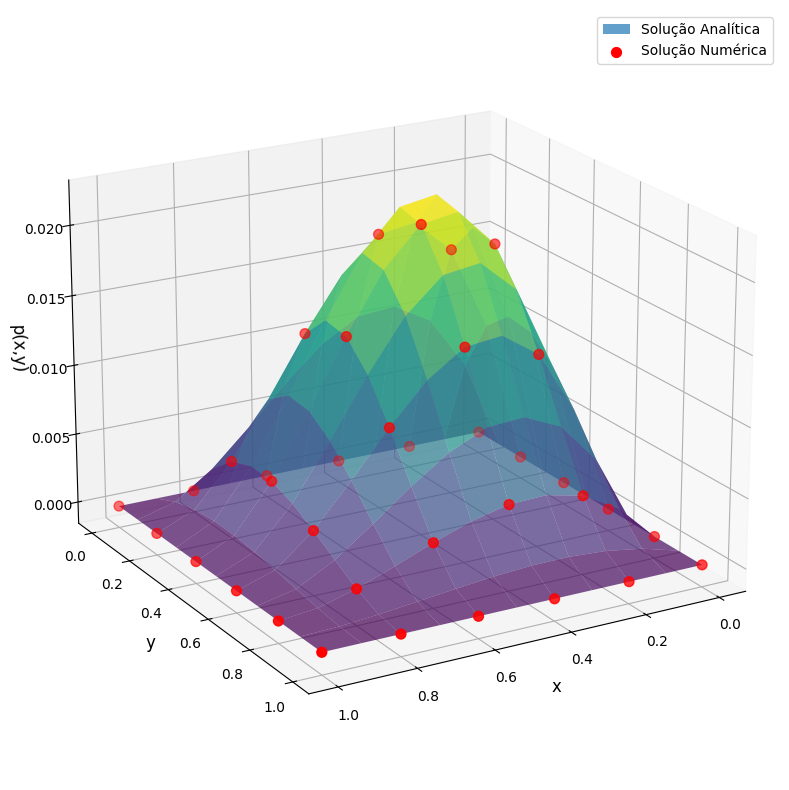

In [ ]:
# Plota a solução analítica como superfície e a numérica como pontos
plot_3d_comparison(x_.flatten(), y_.flatten(), p.data[0], f_analytical)